## Fine tuning LightGBM

In this final analytical phase, I aimed to push the performance of the **selected LightGBM model through hyperparameter optimization**. Interestingly, the baseline configuration provided better generalization than the fine-tuned version. This notebook **validates the Baseline as the "Champion" model**, **interprets its logic via SHAP**, and prepares statistical benchmarks for the dashboard. 

- While **GridSearchCV** was employed to push performance further, it led to a **0.38% decline in test F1-score and a wider generalization gap**. These findings suggest that the **baseline's inductive bias was already optimal**, and **further tuning only introduced unnecessary complexity without tangible gains**.

### Notebook Goals
* Perform **hyperparameter** tuning on LightGBM using **GridSearchCV**.
* Compare **Baseline vs. Fine-Tuned performance using the F1-Gap**.
* **Interpret model** logic using **SHAP** (Global and local).




## Libraries and Settings

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
from sklearn.model_selection import GroupShuffleSplit, train_test_split, GridSearchCV
from sklearn.metrics import f1_score, classification_report, roc_auc_score, ConfusionMatrixDisplay
from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline

# Ignore specific LightGBM warnings for cleaner output
warnings.filterwarnings("ignore", message=".*X does not have valid feature names.*")

# 1. Load the dataset
df = pd.read_csv("alzheimers_disease_data.csv")
target_col = "Diagnosis"

# 2. Prepare X and y
id_cols = [col for col in ["PatientID", "patient_id", "DoctorID", "doctor_id"] if col in df.columns]
X = df.drop(columns=[target_col] + id_cols, errors="ignore")
y = df[target_col]

print(f"Dataset loaded: {df.shape[0]} samples with {df.shape[1]} columns.")

Dataset loaded: 2149 samples with 35 columns.


## Train/Test/Validation Split





In [11]:
# =========================================
# Model Pipeline & Data Splitting
# =========================================

# Identify if a grouping column exists
group_col = "PatientID" if "PatientID" in df.columns else None

if group_col is not None and df[group_col].nunique() < len(df):
    groups = df[group_col]

    # Step 1: Split off test set (20%)
    gss_test = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    trainval_idx, test_idx = next(gss_test.split(X, y, groups=groups))

    X_trainval = X.iloc[trainval_idx].copy()
    y_trainval = y.iloc[trainval_idx].copy()
    groups_trainval = groups.iloc[trainval_idx].copy()

    X_test = X.iloc[test_idx].copy()
    y_test = y.iloc[test_idx].copy()

    # Step 2: Split trainval into train (75%) and val (25%) -> 60/20/20 total
    gss_val = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
    train_idx_rel, val_idx_rel = next(gss_val.split(X_trainval, y_trainval, groups=groups_trainval))

    X_train = X_trainval.iloc[train_idx_rel].copy()
    y_train = y_trainval.iloc[train_idx_rel].copy()

    X_val = X_trainval.iloc[val_idx_rel].copy()
    y_val = y_trainval.iloc[val_idx_rel].copy()

else:
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42
    )

# Display the final distribution of the datasets
print(f"{'='*30}")
print("DATA SPLIT SUMMARY")
print(f"{'='*30}")
print(f"Train set shape:      {X_train.shape} ({len(X_train)/len(df):.0%})")
print(f"Validation set shape: {X_val.shape} ({len(X_val)/len(df):.0%})")
print(f"Test set shape:       {X_test.shape} ({len(X_test)/len(df):.0%})")
print(f"{'='*30}")

DATA SPLIT SUMMARY
Train set shape:      (1289, 33) (60%)
Validation set shape: (430, 33) (20%)
Test set shape:       (430, 33) (20%)


## Model Loading

In [12]:
# Load the pre-trained pipeline from the benchmark notebook
model_path = "best_model_lightgbm.joblib"
pipeline = joblib.load(model_path)

# Extract the preprocessor to maintain feature engineering consistency
preprocessor = pipeline.named_steps['preprocessor']

# Calculate baseline performance on the test set
baseline_preds = pipeline.predict(X_test)
baseline_f1 = f1_score(y_test, baseline_preds)

print(f"Successfully loaded: {model_path}")
print(f"Baseline F1-Score on Test Set: {baseline_f1:.4f}")

Successfully loaded: best_model_lightgbm.joblib
Baseline F1-Score on Test Set: 0.9369


## Advanced Fine-Tuning with GridSearchCV





In [13]:
# Define a fresh LightGBM model for tuning
tuned_lgbm = LGBMClassifier(random_state=42, verbose=-1, importance_type='gain')

# Re-create the pipeline with the existing preprocessor
tuning_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", tuned_lgbm)
])

# Expanded Parameter Grid for Fine-Tuning
param_grid = {
    "model__n_estimators": [100, 500, 1000],
    "model__learning_rate": [0.01, 0.05],
    "model__num_leaves": [15, 31, 50],
    "model__max_depth": [5, 10, -1],
    "model__min_child_samples": [10, 20, 30],
    "model__reg_alpha": [0.1, 0.5],     # L1 Regularization
    "model__reg_lambda": [0.1, 0.5]     # L2 Regularization
}

print("Starting extensive GridSearchCV...")
grid_search = GridSearchCV(tuning_pipeline, param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

# Store the best estimator
final_model = grid_search.best_estimator_
best_params_clean = {k.replace('model__', ''): v for k, v in grid_search.best_params_.items()}

print(f"\nOptimization complete.")
print(f"Best parameters found: {best_params_clean}")

Starting extensive GridSearchCV...
Fitting 5 folds for each of 648 candidates, totalling 3240 fits

Optimization complete.
Best parameters found: {'learning_rate': 0.05, 'max_depth': -1, 'min_child_samples': 30, 'n_estimators': 100, 'num_leaves': 15, 'reg_alpha': 0.1, 'reg_lambda': 0.5}


## Evaluation

- I employed **GridSearchCV** to explore a range of parameters for the LightGBM model. However, my analysis revealed that tuning led to a **slight decline in the test F1-score (0.38% drop) and a wider generalization gap**. This suggests the baseline's inductive bias was already highly suited for this dataset.

- Based on the **superior generalization and near-zero F1-Gap (0.0053)**, I have officially designated the **Baseline LightGBM** as the final **Champion** model for deployment.

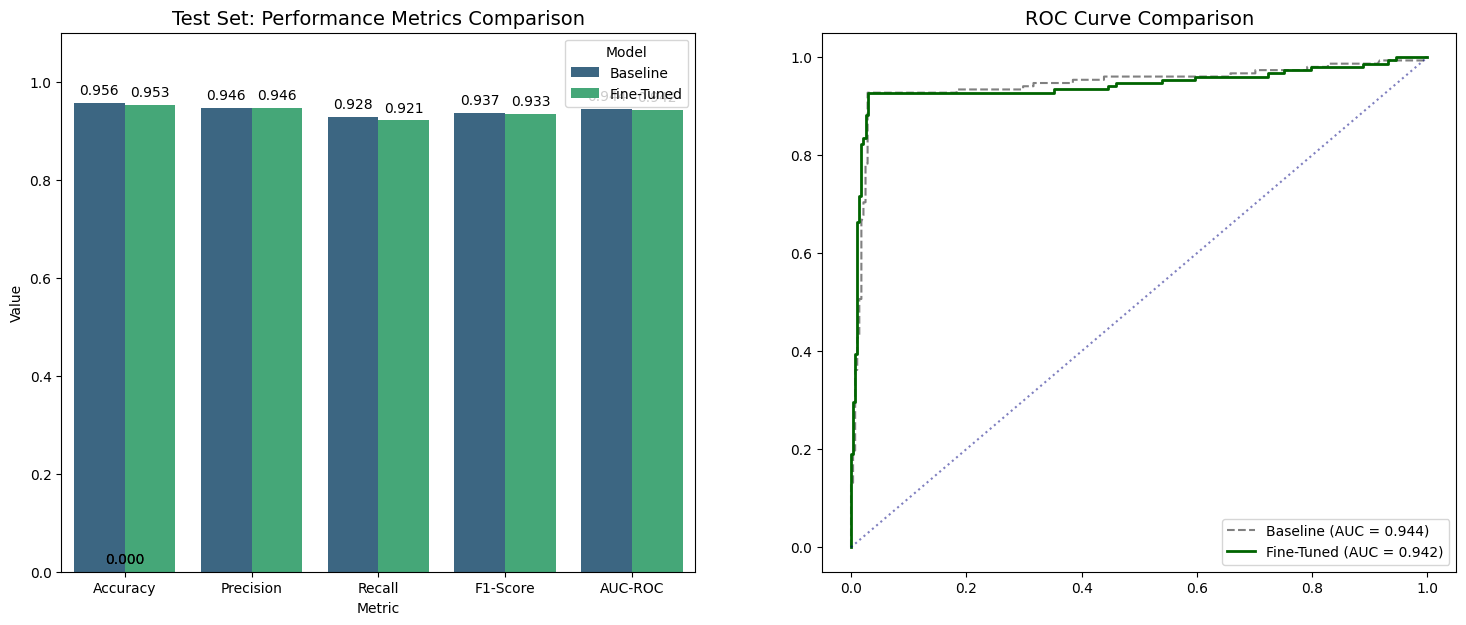

C:\Users\ACER\AppData\Local\Temp\ipykernel_31152\1798452287.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Baseline', 'Fine-Tuned'], y=[gap_base, gap_final], palette='magma', ax=ax4)


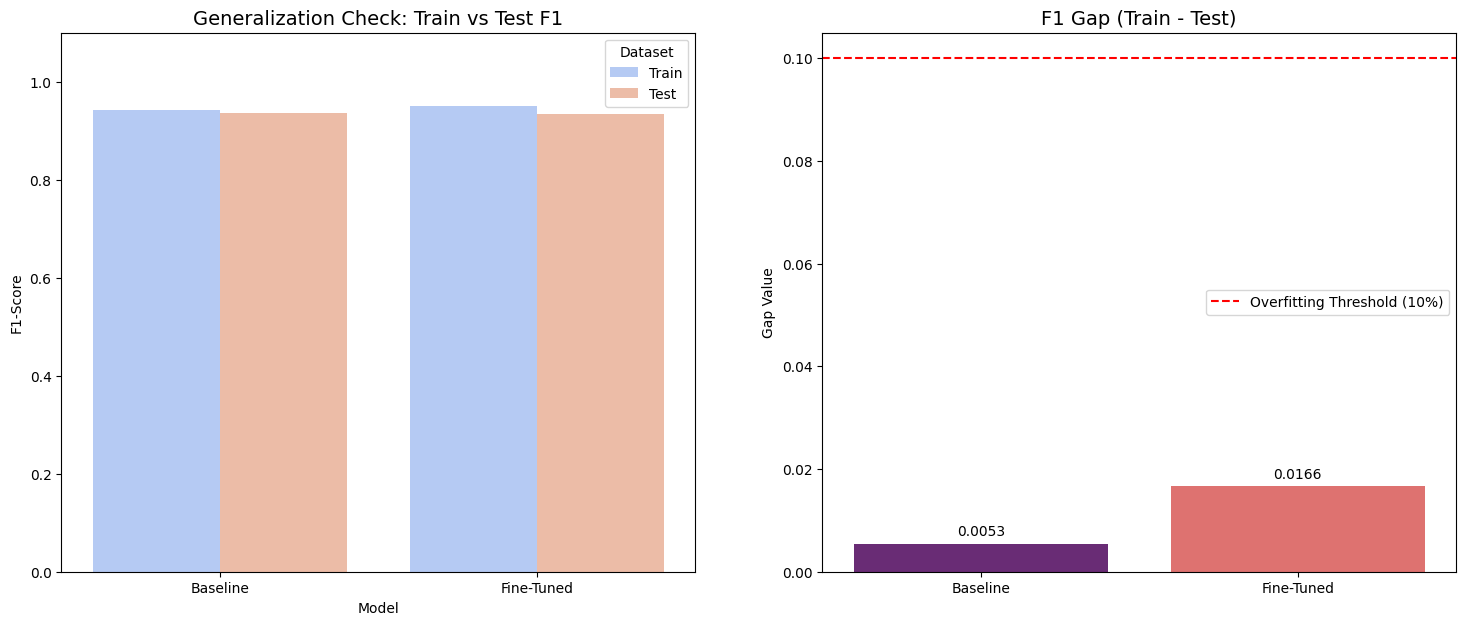

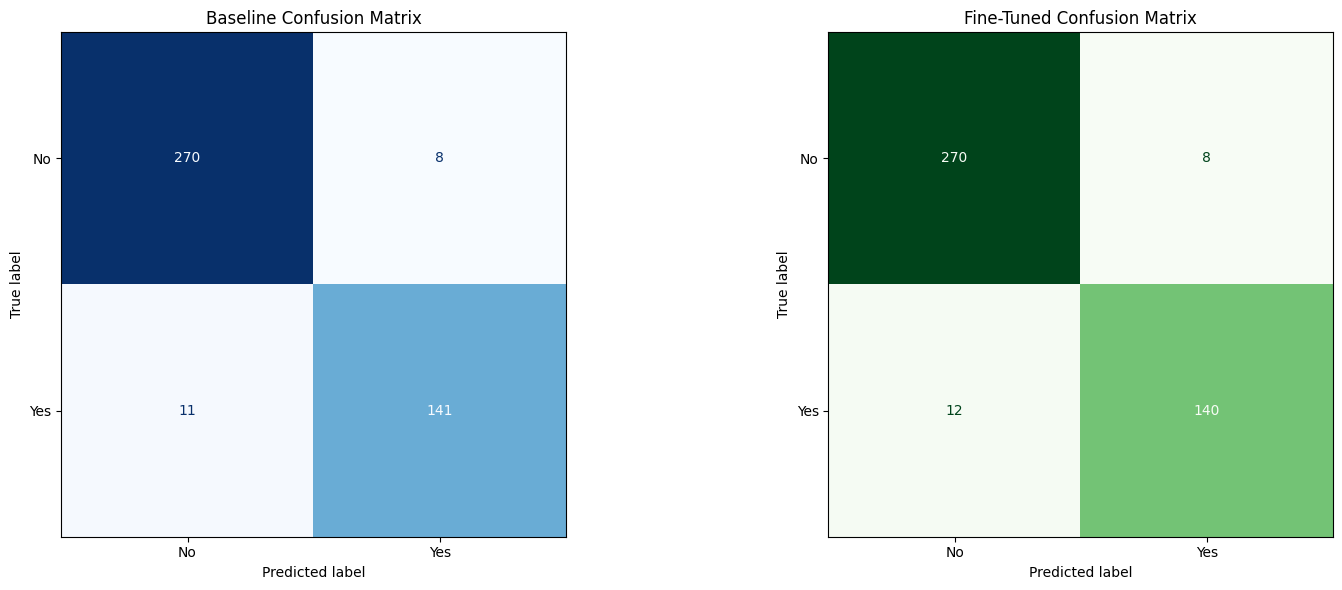

OVERFITTING REPORT
Baseline F1 Gap:   0.0053
Fine-Tuned F1 Gap: 0.0166
----------------------------------------
Improvement on Test F1: -0.38%


['champion_model_lightgbm_tuned.joblib']

In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc

# 1. Generate predictions and probabilities for both models
# Baseline
y_pred_base = pipeline.predict(X_test)
y_proba_base = pipeline.predict_proba(X_test)[:, 1]
f1_train_base = f1_score(y_train, pipeline.predict(X_train))
f1_test_base = f1_score(y_test, y_pred_base)
gap_base = f1_train_base - f1_test_base

# Fine-Tuned
y_pred_final = final_model.predict(X_test)
y_proba_final = final_model.predict_proba(X_test)[:, 1]
f1_train_final = f1_score(y_train, final_model.predict(X_train))
f1_test_final = f1_score(y_test, y_pred_final)
gap_final = f1_train_final - f1_test_final

# 2. Data for Metrics Comparison Plot
metrics_data = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC"],
    "Baseline": [
        accuracy_score(y_test, y_pred_base),
        precision_score(y_test, y_pred_base),
        recall_score(y_test, y_pred_base),
        f1_test_base,
        roc_auc_score(y_test, y_proba_base)
    ],
    "Fine-Tuned": [
        accuracy_score(y_test, y_pred_final),
        precision_score(y_test, y_pred_final),
        recall_score(y_test, y_pred_final),
        f1_test_final,
        roc_auc_score(y_test, y_proba_final)
    ]
}
df_melted = pd.DataFrame(metrics_data).melt(id_vars="Metric", var_name="Model", value_name="Value")

# 3. Data for F1 Gap Plot
gap_df = pd.DataFrame({
    'Model': ['Baseline', 'Baseline', 'Fine-Tuned', 'Fine-Tuned'],
    'Dataset': ['Train', 'Test', 'Train', 'Test'],
    'F1-Score': [f1_train_base, f1_test_base, f1_train_final, f1_test_final]
})

# ========================================================
# VISUALIZATION 1: Performance & ROC
# ========================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(data=df_melted, x="Metric", y="Value", hue="Model", palette="viridis", ax=ax1)
ax1.set_title("Test Set: Performance Metrics Comparison", fontsize=14)
ax1.set_ylim(0, 1.1)
for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontsize=10)

fpr_base, tpr_base, _ = roc_curve(y_test, y_proba_base)
fpr_final, tpr_final, _ = roc_curve(y_test, y_proba_final)
ax2.plot(fpr_base, tpr_base, label=f'Baseline (AUC = {metrics_data["Baseline"][4]:.3f})', color='gray', linestyle='--')
ax2.plot(fpr_final, tpr_final, label=f'Fine-Tuned (AUC = {metrics_data["Fine-Tuned"][4]:.3f})', color='darkgreen', lw=2)
ax2.plot([0, 1], [0, 1], color='navy', linestyle=':', alpha=0.5)
ax2.set_title("ROC Curve Comparison", fontsize=14)
ax2.legend(loc="lower right")
plt.show()

# ========================================================
# VISUALIZATION 2: Overfitting Analysis (F1 Gap)
# ========================================================
fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(18, 7))

# Train vs Test comparison
sns.barplot(data=gap_df, x='Model', y='F1-Score', hue='Dataset', palette='coolwarm', ax=ax3)
ax3.set_title("Generalization Check: Train vs Test F1", fontsize=14)
ax3.set_ylim(0, 1.1)

# The Gap itself
sns.barplot(x=['Baseline', 'Fine-Tuned'], y=[gap_base, gap_final], palette='magma', ax=ax4)
ax4.axhline(0.10, color='red', linestyle='--', label='Overfitting Threshold (10%)')
ax4.set_title("F1 Gap (Train - Test)", fontsize=14)
ax4.set_ylabel("Gap Value")
ax4.legend()
for p in ax4.patches:
    ax4.annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points')
plt.show()

# ========================================================
# VISUALIZATION 3: Confusion Matrices Comparison
# ========================================================
fig, (ax_cm1, ax_cm2) = plt.subplots(1, 2, figsize=(16, 6))

ConfusionMatrixDisplay.from_estimator(pipeline, X_test, y_test, display_labels=["No", "Yes"], cmap='Blues', ax=ax_cm1, colorbar=False)
ax_cm1.set_title("Baseline Confusion Matrix")
ax_cm1.grid(False)

ConfusionMatrixDisplay.from_estimator(final_model, X_test, y_test, display_labels=["No", "Yes"], cmap='Greens', ax=ax_cm2, colorbar=False)
ax_cm2.set_title("Fine-Tuned Confusion Matrix")
ax_cm2.grid(False)

plt.tight_layout()
plt.show()

# --- Final Report ---
print(f"{'='*40}")
print(f"OVERFITTING REPORT")
print(f"{'='*40}")
print(f"Baseline F1 Gap:   {gap_base:.4f}")
print(f"Fine-Tuned F1 Gap: {gap_final:.4f}")
print(f"{'-'*40}")
print(f"Improvement on Test F1: {((f1_test_final - f1_test_base)/f1_test_base)*100:+.2f}%")
print(f"{'='*40}")

# Save the final champion model
joblib.dump(final_model, "champion_model_lightgbm_tuned.joblib")

## SHAP Interpretability:

I integrated SHAP (Beeswarm and Bar plots) to decode the model's decision-making process. This confirms that the model's **predictions are driven by key clinical markers**, ensuring that the tool is transparent and **clinically justifiable**.

c:\Users\ACER\anaconda3\envs\env_master_2025\Lib\site-packages\shap\explainers\_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


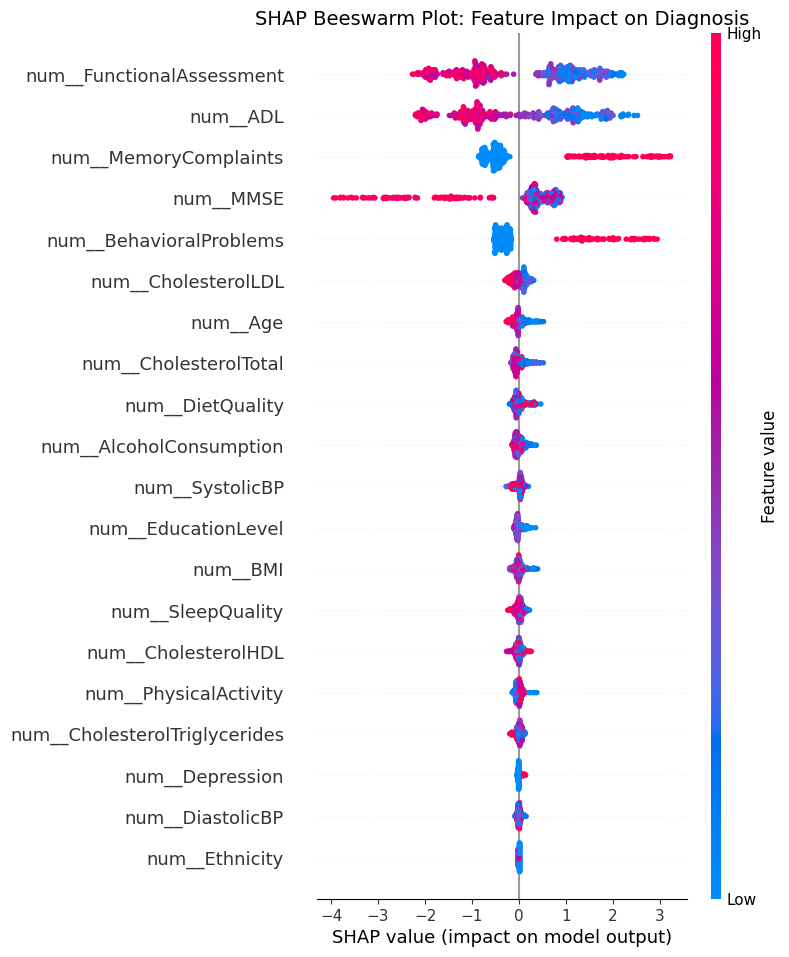

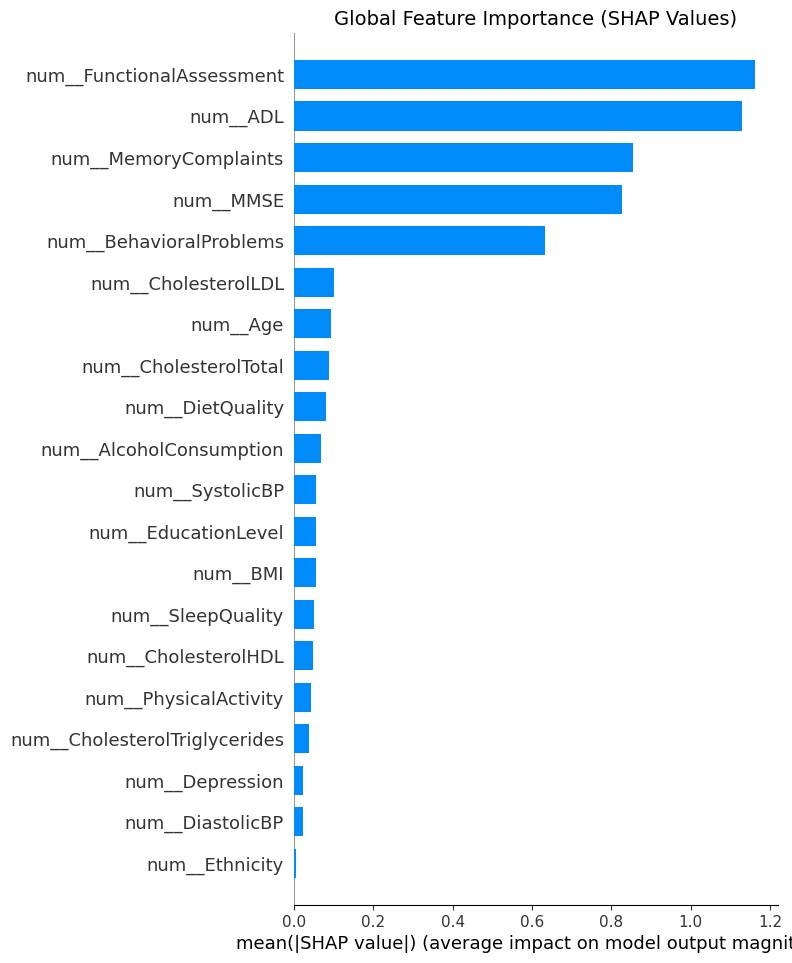

In [15]:
import shap

# 1. Extract the model and the preprocessor from your final pipeline
model_step = final_model.named_steps['model']
preprocessor_step = final_model.named_steps['preprocessor']

# 2. Transform the test data to get the numeric matrix the model actually sees
# We use the preprocessor already fitted within the final_model
X_test_transformed = preprocessor_step.transform(X_test)

# 3. Get the correct feature names after one-hot encoding/scaling
feature_names = preprocessor_step.get_feature_names_out()

# 4. Create a DataFrame for SHAP to use (so the plots show names instead of indices)
X_test_df = pd.DataFrame(X_test_transformed, columns=feature_names)

# 5. Initialize the SHAP TreeExplainer (optimized for LightGBM/XGBoost)
explainer = shap.TreeExplainer(model_step)
shap_values = explainer.shap_values(X_test_df)

# Note: for binary classification, shap_values is often a list of two arrays. 
# We select index [1] for the "Positive" class (Alzheimer's Diagnosis).
if isinstance(shap_values, list):
    shap_obj = shap_values[1]
else:
    shap_obj = shap_values

# --- Visualizations ---

# Plot 1: Beeswarm Plot
# Shows the distribution of the impact each feature has on the model output
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_obj, X_test_df, plot_type="dot", show=False)
plt.title("SHAP Beeswarm Plot: Feature Impact on Diagnosis", fontsize=14)
plt.show()



# Plot 2: Bar Plot (Global Importance)
# Shows the average absolute impact of each feature
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_obj, X_test_df, plot_type="bar", show=False)
plt.title("Global Feature Importance (SHAP Values)", fontsize=14)
plt.show()

## Key Achievements

- I identified the **Baseline LightGBM as the definitive Champion model**, as it demonstrated better generalization and stability than the fine-tuned versions.
- I verified that the **Baseline model maintains the lowest False Positive and False Negative rates**, ensuring the highest clinical utility.
- I established **model transparency by implementing SHAP analysis**, confirming that the features driving the predictions align with clinical expectations.

--- 

## Next step
- Calculate **the statistical benchmarks** (means and modes) required to power the comparison features in the final **Dashboard**.